In [1]:

import sys
import os
import warnings
warnings.simplefilter("ignore")
# parentdir = os.path.abspath('../..')
# sys.path.insert(0, parentdir) 
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_enable_triton_softmax_fusion=true '
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_async_collectives=true '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
    '--xla_gpu_enable_highest_priority_async_stream=true '
)
if 'graphviz' not in os.environ['PATH']:
    os.environ['PATH'] = '/opt/apps/pkgs/graphviz/12.2.1/intel64/gnu_12.2.0/bin:' + os.environ['PATH']

[CudaDevice(id=0)]


In [2]:
pix_scale = 0.031  # arcsec / pixel (JWST)

DATA_DIR = "../../Data/WFI2033"
raw_data_path = os.path.join(DATA_DIR, "jw01198-o004_t004_nircam_clear-f115w_i2d.fits")
data_path = os.path.join(DATA_DIR, "jw01198-o004_t004_nircam_clear-f115w_i2d_cut_x6985_y3594_150.fits")
mask_path = os.path.join(DATA_DIR, "mask.fits")
maskout_path = os.path.join(DATA_DIR, "mask_out.fits")

with fits.open(raw_data_path, memmap=True) as hdul_raw:
    exposure_time = float(hdul_raw[0].header.get("EXPTIME", hdul_raw[0].header.get("TEXPTIME", 1.0)))

with fits.open(data_path, memmap=True) as hdul:
    data = jnp.array(hdul["SCI"].data) if "SCI" in hdul else jnp.array(hdul[0].data)
    rms_file = jnp.array(hdul["ERR"].data)

mask = jnp.array(fits.getdata(mask_path), dtype=bool)
mask_out = jnp.array(1-fits.getdata(maskout_path), dtype=bool)
mask = jnp.array(mask_out, dtype=bool)

valid = jnp.isfinite(data) & jnp.isfinite(rms_file) & (rms_file > 0)
mask = mask & valid
npix = int(mask_out.sum())

corner_pixel = 10
bkg_corner = np.array(data[:corner_pixel, :corner_pixel])
bkg_mean = float(np.nanmean(bkg_corner))
bkg_rms = float(np.nanstd(bkg_corner))

data = data - bkg_mean
rms = float(np.nanmedian(np.array(rms_file[mask_out])))

# Assume Step 3 PSF output format is as expected
psf_path_model = os.path.join("./psf_data", "PSF_model_step3_svi.fits")
with fits.open(psf_path_model, memmap=True) as hdul_psf:
    psf_hst = np.array(hdul_psf["DET_PSF_MODEL"].data, dtype=float)

psf_hst = np.clip(psf_hst, 0.0, None)
psf_hst = psf_hst / np.sum(psf_hst)
psf_used = psf_path_model
psf = PSF(psf_type='PIXEL', kernel_point_source=psf_hst)

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(data, pix_scale)
noise = Noise(nx, ny, exposure_time=exposure_time)
provided_rms = True

N_gauss_light = 15
N_gauss_source = 1

sigma_lims_lens = [0.00001, 1.0]
sigma_lims = [0.01, 0.5]

lens_light_ps_pos = jnp.array([0.5, -0.1])

source_grid_scale = 0.5

conj_points = jnp.array([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
])

ss_factor = 2

PSF_CORNER_SIZE = 5

def compute_psf_corner_median(psf_kernel, corner_size=PSF_CORNER_SIZE):
    ny, nx = psf_kernel.shape
    cs = min(corner_size, ny, nx)
    corners = np.concatenate([
        psf_kernel[:cs, :cs].reshape(-1),
        psf_kernel[:cs, -cs:].reshape(-1),
        psf_kernel[-cs:, :cs].reshape(-1),
        psf_kernel[-cs:, -cs:].reshape(-1),
    ])
    return float(np.nanmedian(corners))

psf_corner_median = compute_psf_corner_median(psf_hst, corner_size=PSF_CORNER_SIZE)

def subtract_psf_corner_median(model_image, psf_median=psf_corner_median):
    return model_image - jnp.asarray(psf_median, dtype=model_image.dtype)



PSF_CORR_PRIOR = {
    "plate_name": "PSF correction",
    "param_name": "log_psf_corr_center",
    "box_size_pix": 50,
    "sigma_log": 1.0,
    "log_clip": 5.0,
}

k_psf = K_grid(psf_hst.shape).k


def build_psf_corr_factor_field(log_psf_corr_center, psf_shape, box_size_pix=50, log_clip=5.0):
    ny, nx = psf_shape
    d = int(box_size_pix)
    if d <= 0:
        raise ValueError('box_size_pix must be a positive integer')
    d = min(d, ny, nx)

    yc = ny // 2
    xc = nx // 2
    y0 = yc - d // 2
    x0 = xc - d // 2
    y1 = y0 + d
    x1 = x0 + d

    log_patch = jnp.asarray(log_psf_corr_center)[:d, :d]
    corr_patch = jnp.exp(jnp.clip(log_patch, -log_clip, log_clip))

    field = jnp.ones((ny, nx))
    return field.at[y0:y1, x0:x1].set(corr_patch)


def build_corrected_psf_kernel(psf_base, log_psf_corr_center, eps=1e-12):
    corr_field = build_psf_corr_factor_field(
        log_psf_corr_center,
        jnp.asarray(psf_base).shape,
        box_size_pix=PSF_CORR_PRIOR["box_size_pix"],
        log_clip=PSF_CORR_PRIOR["log_clip"],
    )
    psf_eff = jnp.asarray(psf_base) * corr_field
    psf_eff = jnp.maximum(psf_eff, eps)
    psf_eff = psf_eff / (jnp.sum(psf_eff) + eps)
    return psf_eff


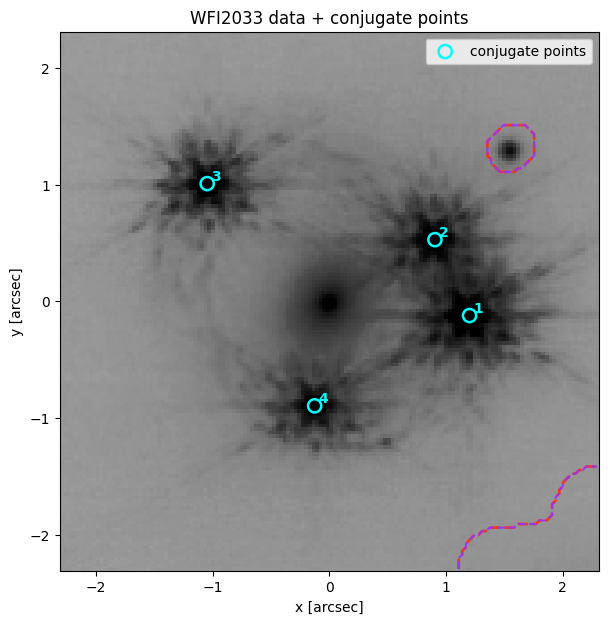

In [3]:
# Quick data visualization (same style as old JWST notebook)
plt.figure(figsize=(8, 7))
plt.imshow(
    np.array(data),
    origin='lower',
    cmap='Grays',
    extent=extent,
    norm=colors.SymLogNorm(linthresh=1, vmax=10.5, vmin=-10),
)
plt.contour(np.array(mask), levels=[0.5], colors='#ff3300', alpha=0.95, linewidths=2, linestyles='dashed', origin='lower', extent=extent)
plt.contour(np.array(mask_out), levels=[0.5], colors='#9933ff', alpha=0.95, linestyles='dashed', origin='lower', extent=extent)

# Overlay conjugate point positions
conj_np = np.array(conj_points, dtype=float)
plt.scatter(
    conj_np[:, 0],
    conj_np[:, 1],
    s=90,
    facecolors='none',
    edgecolors='cyan',
    linewidths=1.8,
    marker='o',
    label='conjugate points',
)
for i, (x, y) in enumerate(conj_np, start=1):
    plt.text(x + 0.03, y + 0.03, str(i), color='cyan', fontsize=10, weight='bold')

plt.title('WFI2033 data + conjugate points')
plt.xlabel('x [arcsec]')
plt.ylabel('y [arcsec]')
plt.legend(loc='upper right')
plt.show()


In [4]:
# Prior config block
MASS_PRIOR_PARAMETRIC = {
    'gamma_low': 1.95,
    'gamma_up': 2.05,
    'center_high': 0.5,
    'center_low': -0.5,
}

MASS_PRIOR_PIXELATED = {}

LENS_LIGHT_PRIOR_KWARGS = {
    'plate_name': 'Lens light',
    'param_name': 'lens',
    'n_gauss': N_gauss_light,
    'sigma_lims': sigma_lims_lens,
    'e_low': -0.2,
    'e_high': 0.2,
}

POINT_SOURCE_PRIOR = {
    'pos_sigma': 0.05,
    'pos_window': 0.2,
    'log10_amp_low': -3.0,
    'log10_amp_high': 4.5,
    'log10_amp_lens_low': -3.0,
    'log10_amp_lens_high': 4.5,
}

CONJUGATE_POINT_PRIOR = {
    'rate': {
        'parametric': 1000.0,
        'pixelated': 100.0,
    },
}

RMS_PRIOR = {
    'low_factor': 0.5,
    'high_factor': 1.5,
}

SOURCE_GRID_PRIOR = {
    'plate_name': 'Source grid',
    'param_name': 'source_grid',
    'n_high': 1000,
    'positive': True,
}



In [5]:
# Data-loading diagnostics removed by design.


In [6]:
from herculens.PointSourceModel.point_source_model import PointSourceModel

mass_model = MassModel(['EPL', 'SHEAR'])

lens_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

point_source_model = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model,
    image_plane=pixel_grid,
)

lens_image = LensImageExtension(
    pixel_grid,
    psf,
    noise_class=noise,
    lens_light_model_class=lens_light_model,
    lens_mass_model_class=mass_model,
    source_model_class=source_light_model,
    point_source_model_class=point_source_model,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale = source_grid_scale
)


In [7]:
npix = int(mask_out.sum())
N_HIGH_SOURCE_GRID = SOURCE_GRID_PRIOR['n_high']

def model(data, k_values=None, conj=True, provided_rms=False, pixelated=False, n_value=None, mass_prior_kwargs={}, psf_kernel=None, k_psf_values=None, enable_psf_corr=False):
    mass_params = EPL_w_shear('Mass model', '1', **mass_prior_kwargs)
    lens_light = multi_gauss_light(**LENS_LIGHT_PRIOR_KWARGS)

    n_ps = conj_points.shape[0]
    ra_ps = numpyro.sample(
        'ra_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 0],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    dec_ps = numpyro.sample(
        'dec_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 1],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    log10_amp_ps = numpyro.sample(
        'log10_amp_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_low'],
            POINT_SOURCE_PRIOR['log10_amp_high'],
        ).expand([n_ps]),
    )
    log10_amp_lens_ps = numpyro.sample(
        'log10_amp_lens_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_lens_low'],
            POINT_SOURCE_PRIOR['log10_amp_lens_high'],
        ),
    )

    amp_quasar_ps = jnp.power(10.0, log10_amp_ps)
    amp_lens_ps = jnp.power(10.0, log10_amp_lens_ps)
    kwargs_point_source = [{
        'ra': jnp.concatenate([ra_ps, jnp.array([lens_light_ps_pos[0]])]),
        'dec': jnp.concatenate([dec_ps, jnp.array([lens_light_ps_pos[1]])]),
        'amp': jnp.concatenate([amp_quasar_ps, jnp.array([amp_lens_ps])]),
    }]

    lens_img = lens_image_pixel if pixelated else lens_image

    if conj:
        conj_points_model = lens_img.trace_conjugate_points(mass_params)
        conj_distance = reduced_distance_matrix(conj_points_model)
        nc = conj_distance.shape[0]
        rate_key = 'pixelated' if pixelated else 'parametric'
        conj_rate = CONJUGATE_POINT_PRIOR['rate'][rate_key]
        with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
            numpyro.sample('conjugate_points', dist.Exponential(conj_rate), obs=conj_distance)

    if pixelated:
        if k_values is None:
            raise ValueError('k_values is required when pixelated=True')
        source_light = [
            matern_power_spectrum(
                SOURCE_GRID_PRIOR['plate_name'],
                SOURCE_GRID_PRIOR['param_name'],
                k_values,
                n_high=SOURCE_GRID_PRIOR['n_high'],
                n_value=n_value,
                positive=SOURCE_GRID_PRIOR['positive'],
            )
        ]
    else:
        conj_points_model_for_center = lens_image.trace_conjugate_points(mass_params)
        source_center = jnp.mean(conj_points_model_for_center, axis=0)
        source_light = multi_gauss_light_center(
            'Source light',
            'source',
            N_gauss_source,
            sigma_lims,
            center_det=source_center,
        )

    psf_kernel_eff = psf_kernel

    if pixelated and enable_psf_corr:
        corr_size = int(PSF_CORR_PRIOR["box_size_pix"])
        log_psf_corr_center = numpyro.sample(
            "log_psf_corr_center",
            dist.Normal(
                0.0,
                PSF_CORR_PRIOR["sigma_log"],
            ).expand([corr_size, corr_size]),
        )
        psf_kernel_eff = build_corrected_psf_kernel(
            psf_kernel,
            log_psf_corr_center,
        )

    model_image = lens_img.model(
        kwargs_lens=mass_params,
        kwargs_source=source_light,
        kwargs_lens_light=lens_light,
        kwargs_point_source=kwargs_point_source,
        source_add=True,
        point_source_add=True,
        psf_kernel=psf_kernel_eff,
    )

    if provided_rms:
        model_std = rms_file
    else:
        background_rms_model = numpyro.sample(
            'RMS',
            dist.LogUniform(rms * RMS_PRIOR['low_factor'], rms * RMS_PRIOR['high_factor']),
        )
        model_var = lens_img.Noise.C_D_model(model_image, background_rms=background_rms_model)
        model_std = jnp.sqrt(model_var)

    model_image_masked_out = model_image[mask_out]
    model_std_masked_out = model_std[mask_out]

    numpyro.deterministic('model_image', model_image)

    with numpyro.plate(f'Data masked - [{npix}]', npix):
        numpyro.sample('obs', dist.Normal(model_image_masked_out, model_std_masked_out), obs=data[mask_out])


def params2kwargs(params, fixed_params={}, pixelated=False):
    params_full = params | fixed_params
    kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1')
    kwargs_lens_light = params2kwargs_multi_gauss_light(params_full, 'lens')
    kwargs_point_source = [{
        'ra': jnp.concatenate([params_full['ra_ps'], jnp.array([lens_light_ps_pos[0]])]),
        'dec': jnp.concatenate([params_full['dec_ps'], jnp.array([lens_light_ps_pos[1]])]),
        'amp': jnp.concatenate([
            jnp.power(10.0, params_full['log10_amp_ps']),
            jnp.array([jnp.power(10.0, params_full['log10_amp_lens_ps'])]),
        ]),
    }]

    if pixelated:
        kwargs_source = [params2kwargs_power_spectrum(params_full, 'source_grid')]
    else:
        conj_points_model = lens_image.trace_conjugate_points(kwargs_lens)
        source_center = jnp.mean(conj_points_model, axis=0)
        n_source = params_full['amp_source'].shape[0]
        center_source = jnp.vstack([
            jnp.full((n_source,), source_center[0]),
            jnp.full((n_source,), source_center[1]),
        ])
        params_full = params_full | {'center_source': center_source}
        kwargs_source = params2kwargs_multi_gauss_light(params_full, 'source')

    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': kwargs_source,
        'kwargs_lens_light': kwargs_lens_light,
        'kwargs_point_source': kwargs_point_source,
    }


def params2psf_kernel(params):
    log_psf_corr_center = params['log_psf_corr_center']
    return build_corrected_psf_kernel(psf_hst, log_psf_corr_center)

model_graph = numpyro.render_model(
    model,
    model_args=(data,),
    model_kwargs={
        'pixelated': False,
        'provided_rms': provided_rms,
        'mass_prior_kwargs': MASS_PRIOR_PARAMETRIC,
    },
    render_distributions=True,
)



Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

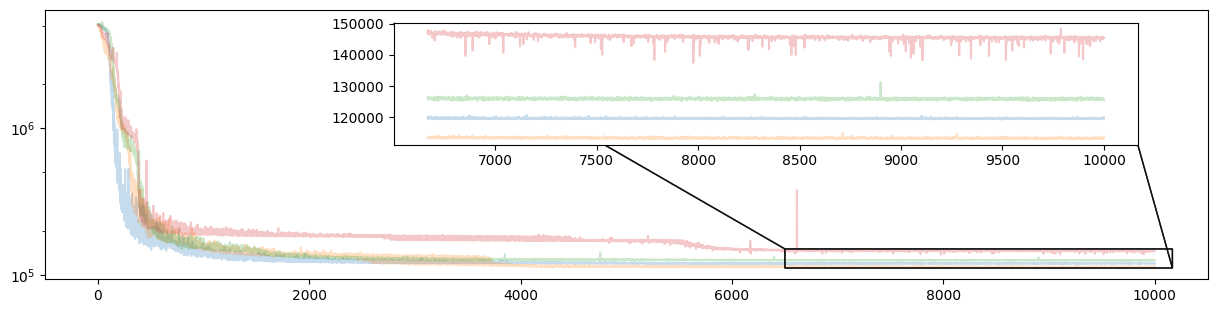

In [8]:
max_iterations = 10000
num_chains = 4

init_fun = infer.init_to_median(num_samples=25)
guide = autoguide.AutoLowRankMultivariateNormal(model, init_loc_fn=init_fun)
scheduler = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim = optax.adabelief(learning_rate=scheduler)
loss = infer.Trace_ELBO (num_particles=1)

rng_key = jax.random.PRNGKey(42)
rng_key, rng_key_ = jax.random.split(rng_key)
svi_keys = jax.random.split(rng_key_, num_chains)
svi = SVI_vec(model, guide, optim, loss)
multi_svi_results = svi.run(rng_key, num_chains, max_iterations, data, provided_rms=provided_rms, mass_prior_kwargs=MASS_PRIOR_PARAMETRIC, stable_update=True)
multi_svi_median = guide.median(multi_svi_results.params)

multi_svi_median_herc = median_params2kwargs(params2kwargs, multi_svi_median, jnp.arange(num_chains))


_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_results.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

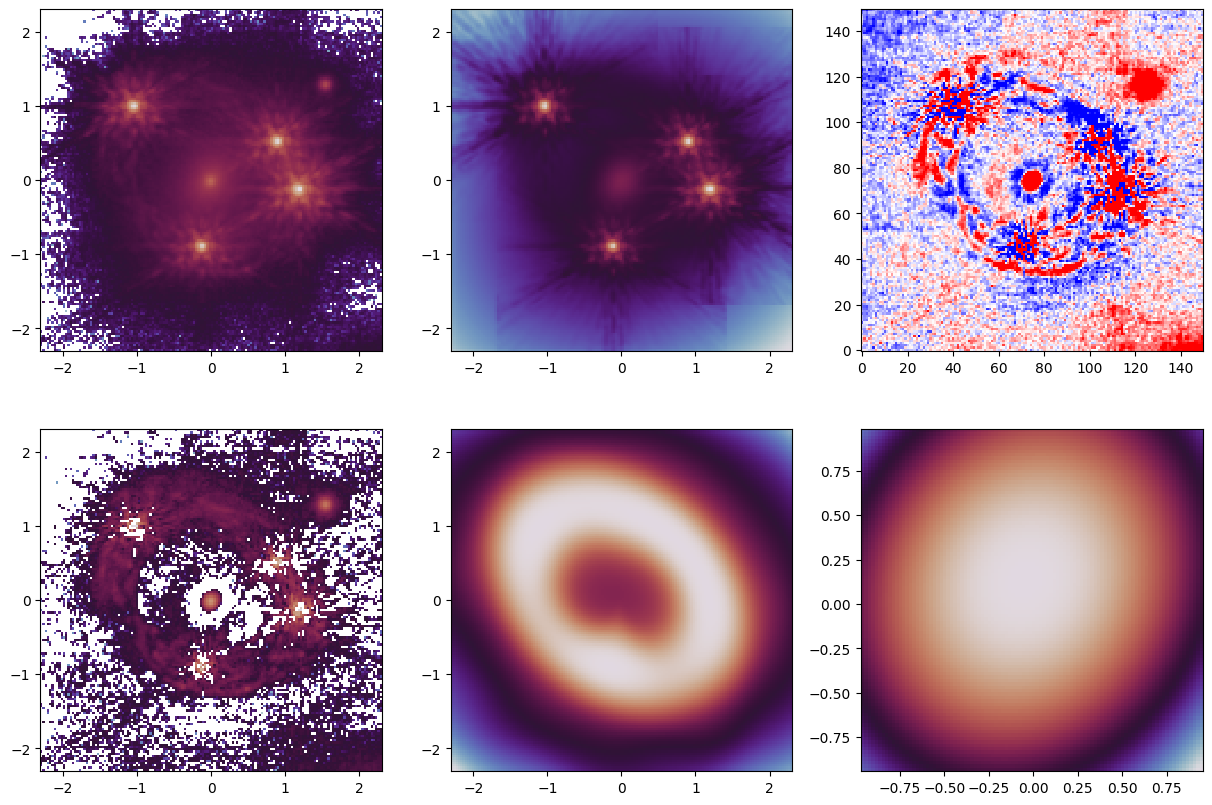

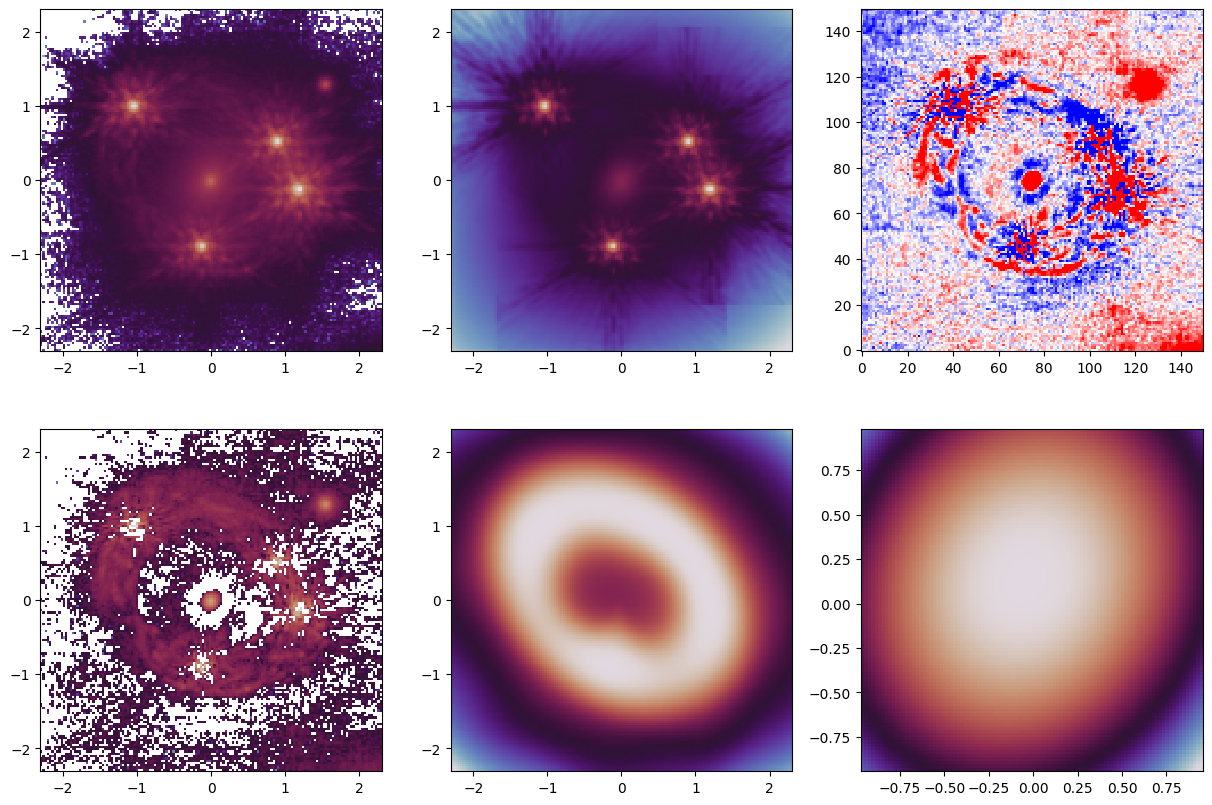

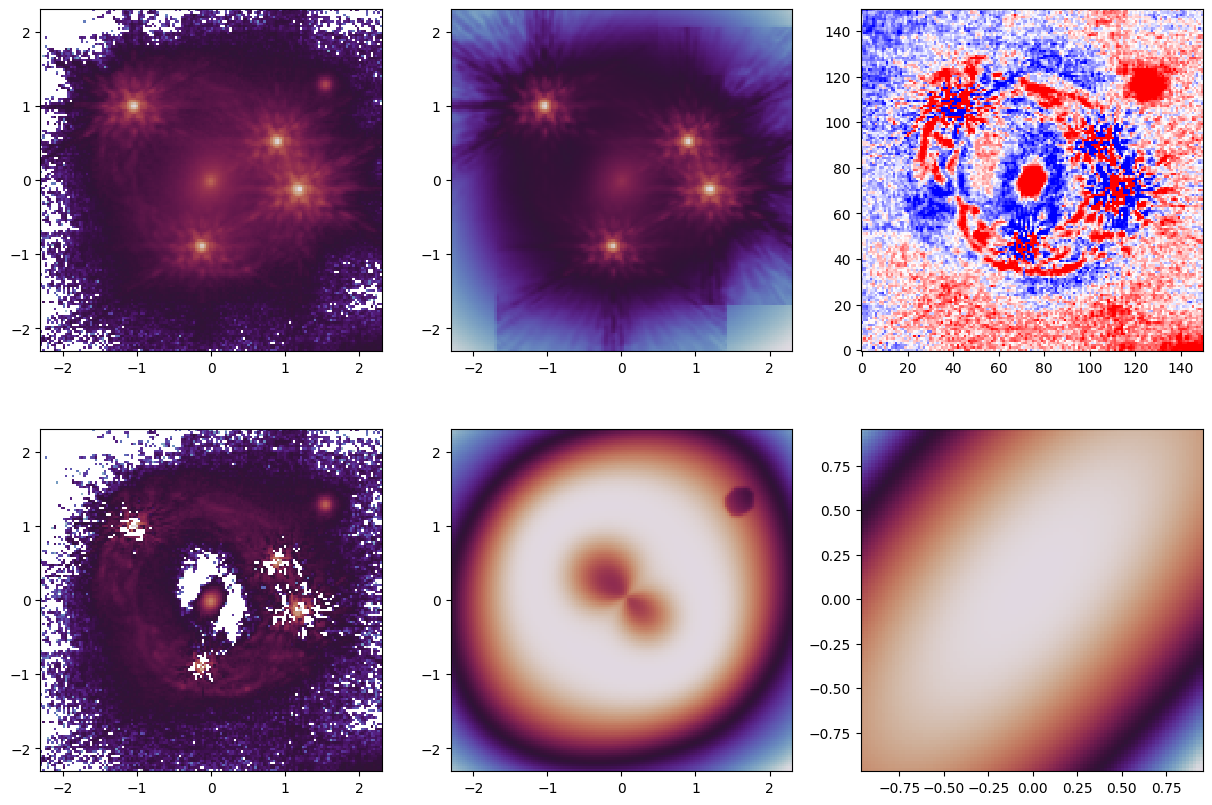

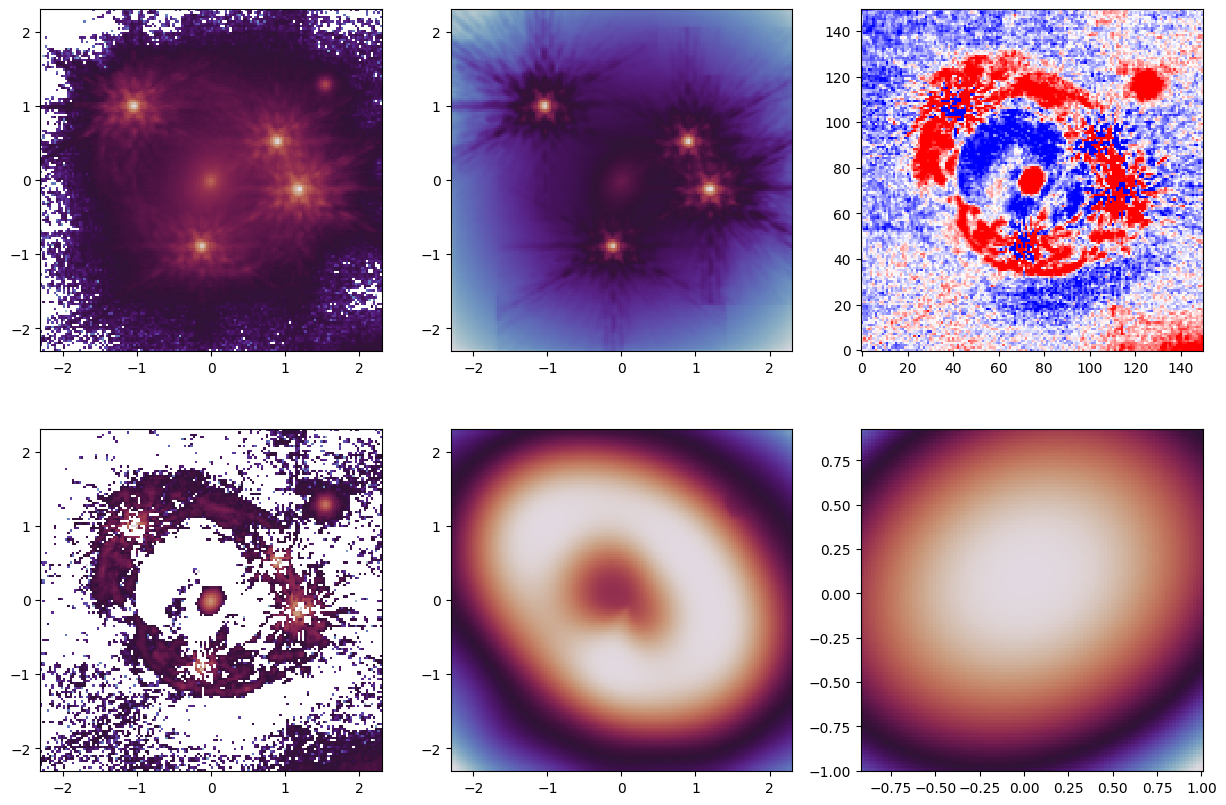

In [9]:
from lens_images_extension import pixelize_plane as pixelize_plane_single

for i in range(4):
    kwargs_i = get_value_from_index(multi_svi_median_herc, i)

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(data, norm='log', cmap='twilight', extent=extent, origin='lower')

    plt.subplot(2, 3, 2)
    image_model = lens_image.model(**kwargs_i, source_add=True)
    plt.imshow(image_model, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 3)
    plt.imshow((data - image_model) / rms_file, cmap='bwr', vmax=3, vmin=-3)

    plt.subplot(2, 3, 4)
    lens_light = lens_image.model(**kwargs_i, source_add=False)
    plt.imshow(data - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 5)
    plt.imshow(image_model - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 6)
    source, source_extent = pixelize_plane_single(
        lens_image,
        kwargs_i,
        100,
    )
    plt.imshow(source, extent=source_extent, norm='log', cmap='twilight')


In [10]:
best_pix_sizes = np.array([
    get_best_pixel_size(
        lens_image,
        get_value_from_index(multi_svi_median_herc, i),
        source_grid_scale
    ) for i in range(num_chains)
])
pixel_grid_shape = np.median(best_pix_sizes).astype(int)*1
# pixel_grid_shape = 50
print(pixel_grid_shape)

84


In [11]:
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens', 'e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_point_source = ['ra_ps', 'dec_ps', 'log10_amp_ps', 'log10_amp_lens_ps']
vars_other = []

svi_samples = guide.sample_posterior(rng_key_, multi_svi_results.params, sample_shape=(1000,))
svi_samples_chains = jax.tree.map(lambda x: jnp.swapaxes(x, 0, 1), svi_samples)
svi_samples_chains = jax.device_get(svi_samples_chains)
multi_svi_guide_sample = az.from_dict(svi_samples_chains)

k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

@jax.vmap
def get_image(idx):
    i, _ = pixelize_plane_single(lens_image, get_value_from_index(multi_svi_median_herc, idx), pixel_grid_shape, source_grid_scale=source_grid_scale)
    return i
orig_source = get_image(jnp.arange(num_chains))
ps_keys = jax.random.split(rng_key_, num_chains)
from herculens_import_main import source_power_spectrum
ps_fits = source_power_spectrum(orig_source, ps_keys, None, True)

keys_for_pixel_init = vars_lens_light + vars_mass + vars_point_source + vars_other
multi_svi_median_pixelated = {k: multi_svi_median[k] for k in keys_for_pixel_init if k in multi_svi_median} | ps_fits



In [12]:
k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

from herculens.PointSourceModel.point_source_model import PointSourceModel

mass_model_pixel = MassModel(['EPL', 'SHEAR'])
lens_light_model_pixel = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model_pixel = LightModel(
    ['PIXELATED',],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape}
)

pixel_grid_pixel = deepcopy(pixel_grid)
psf_pixel = deepcopy(psf)

point_source_model_pixel = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_pixel,
    image_plane=pixel_grid_pixel,
)

lens_image_pixel = LensImageExtension(
    pixel_grid_pixel,
    psf_pixel,
    noise_class=noise,
    lens_light_model_class=lens_light_model_pixel,
    lens_mass_model_class=mass_model_pixel,
    source_model_class=source_light_model_pixel,
    point_source_model_class=point_source_model_pixel,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)



In [13]:
npix = int(mask_out.sum())
N_HIGH_SOURCE_GRID = 1000

model_graph = numpyro.render_model(
    model,
    model_args=(data, k_grid.k),
    model_kwargs={'conj': False, 'pixelated': True, 'provided_rms': provided_rms, 'mass_prior_kwargs': MASS_PRIOR_PIXELATED},
    render_distributions=True,
)


100%|██████████| 10000/10000 [00:36<00:00, 272.28it/s, init loss: 179117.2821, avg. loss [9501-10000]: 99375.4592]


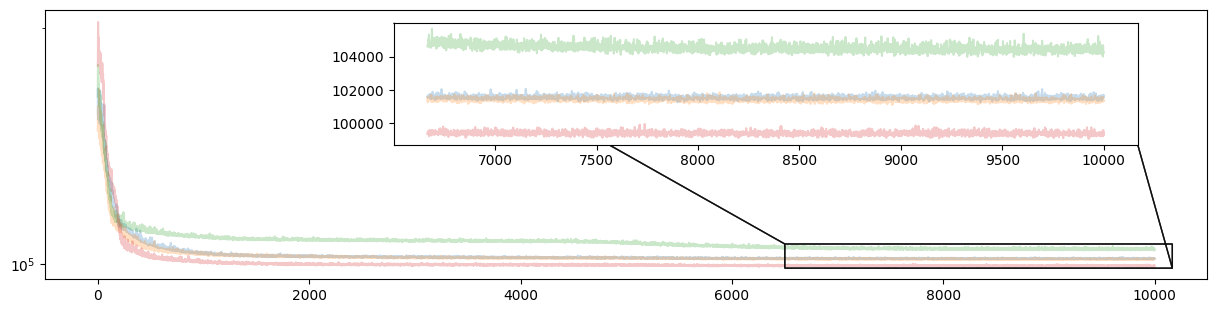

In [14]:
max_iterations = 10000
num_chains = 4

scheduler_stage1 = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim_stage1 = optax.adabelief(learning_rate=scheduler_stage1)
loss_stage1 = infer.TraceMeanField_ELBO()

svi_keys = jax.random.split(rng_key_, num_chains)
stage1_results_list = []
stage1_guides = []

for i in range(num_chains):
    init_fun_stage1_i = init_to_value_or_defer(values=get_value_from_index(multi_svi_median_pixelated, i))
    guide_stage1_i = autoguide.AutoDiagonalNormal(model, init_loc_fn=init_fun_stage1_i, init_scale=0.01)
    svi_stage1_i = infer.SVI(model, guide_stage1_i, optim_stage1, loss_stage1)
    result_i = svi_stage1_i.run(
        svi_keys[i],
        max_iterations,
        data,
        k_grid.k,
        conj=True,
        n_value=None,
        pixelated=True,
        provided_rms=provided_rms,
        mass_prior_kwargs=MASS_PRIOR_PIXELATED,
        progress_bar=True,
        stable_update=True,
        enable_psf_corr=False,
    )
    stage1_guides.append(guide_stage1_i)
    stage1_results_list.append(result_i)


def _stack_or_none(*xs):
    if xs[0] is None:
        return None
    return jnp.stack(xs)


multi_svi_pixel_results_stage1 = jax.tree.map(_stack_or_none, *stage1_results_list)
guide_pixel_stage1 = stage1_guides[0]
multi_svi_pixel_median_stage1 = guide_pixel_stage1.median(multi_svi_pixel_results_stage1.params)
multi_svi_pixel_median_herc_stage1 = median_params2kwargs(
    lambda p, fixed_params={}: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage1,
    jnp.arange(num_chains),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_pixel_results_stage1.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

#383 source pixels: 6120s

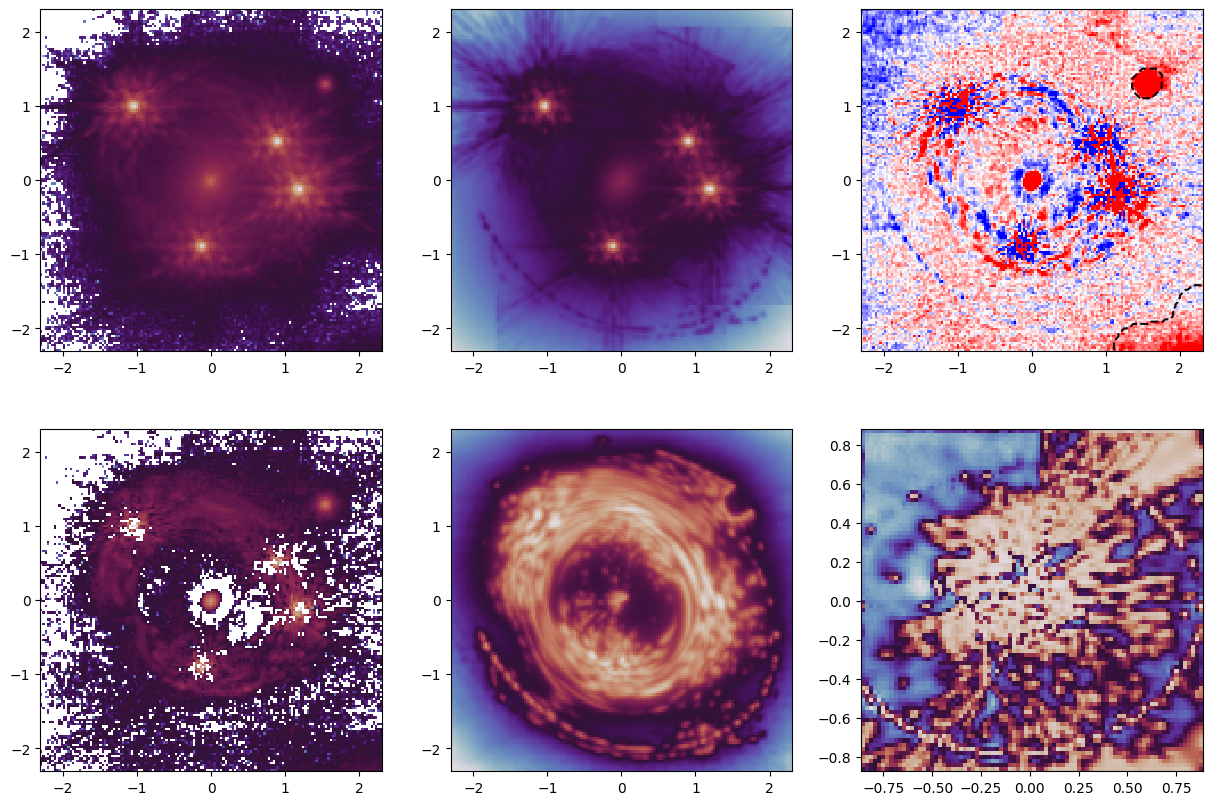

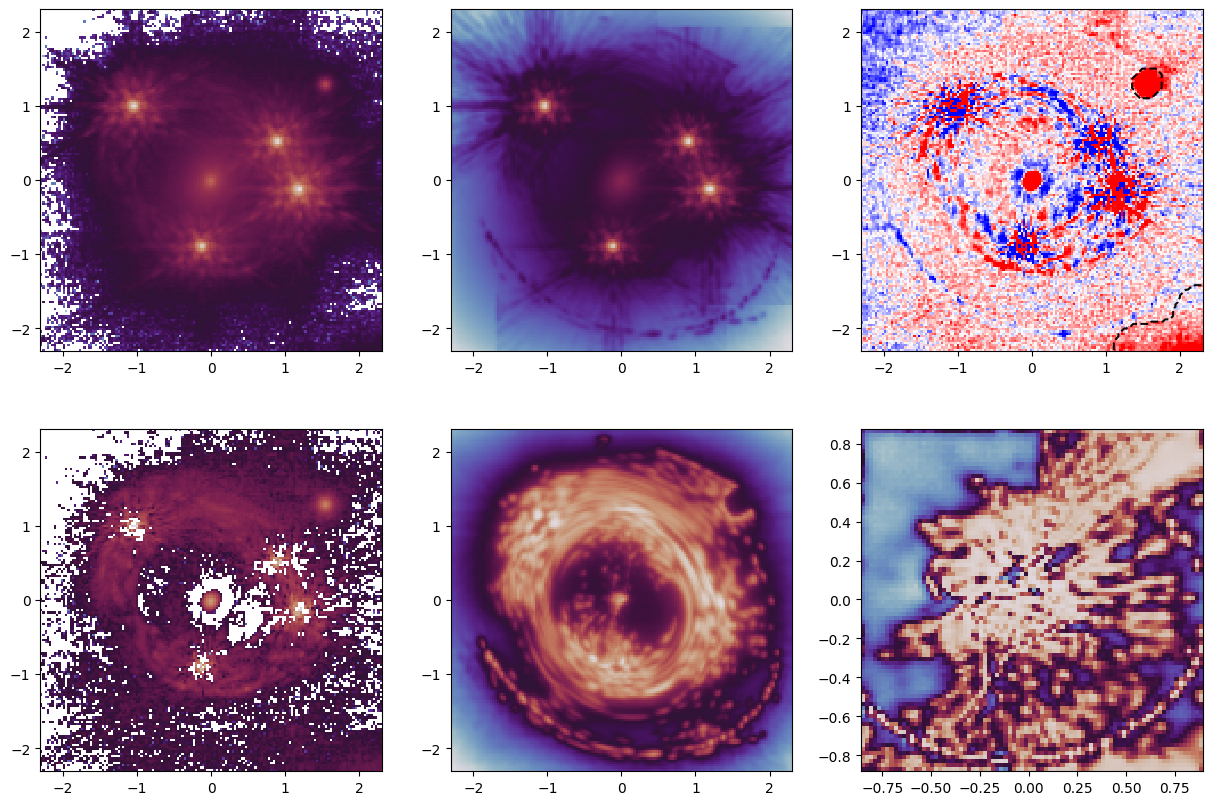

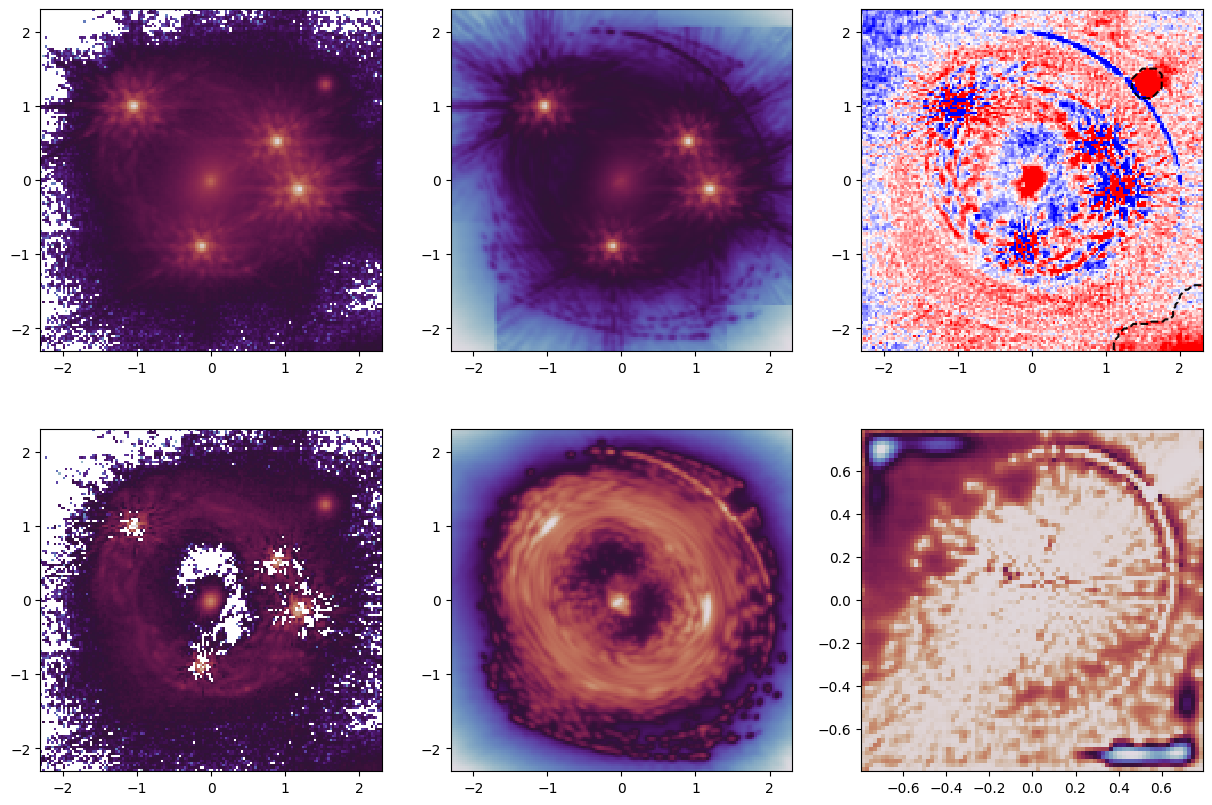

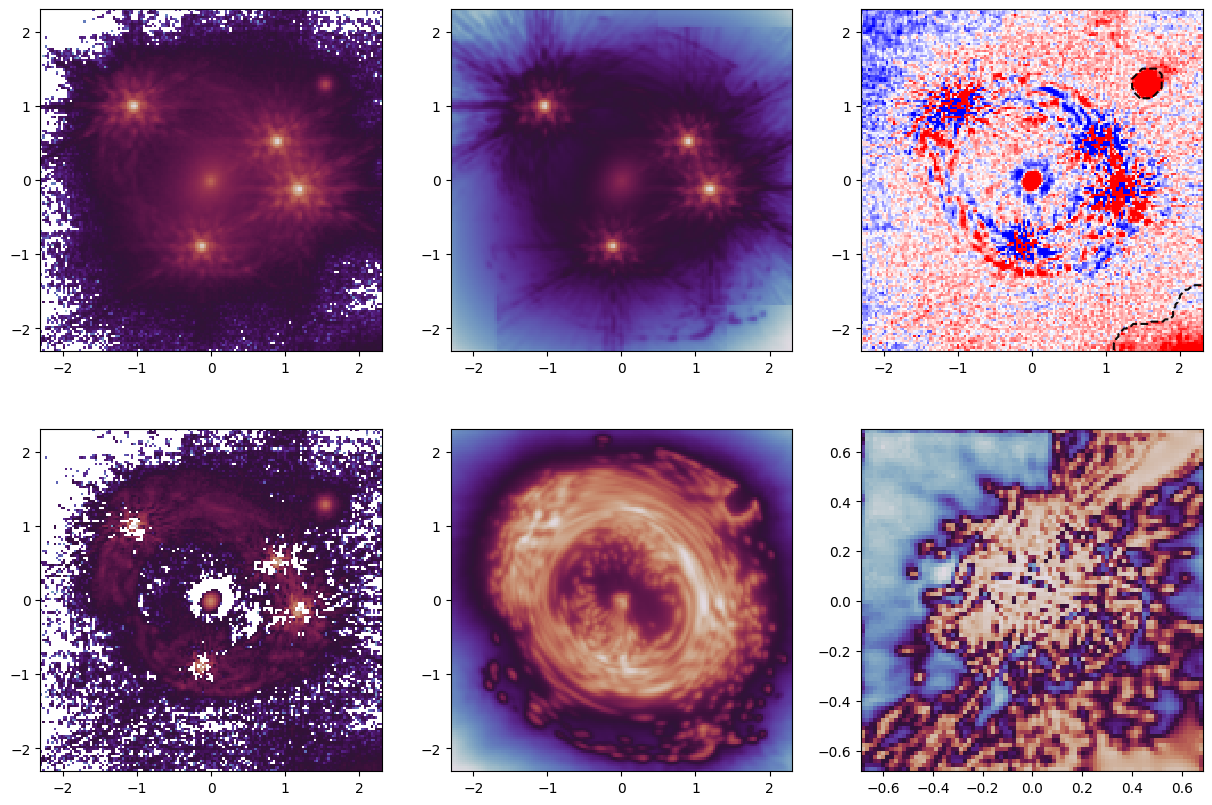

In [15]:
from lens_images_extension import pixelize_plane as pixelize_plane_single

for i in range(4):
    kwargs_i = get_value_from_index(multi_svi_pixel_median_herc_stage1, i)

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(data, norm='log', cmap='twilight', extent=extent, origin='lower')

    plt.subplot(2, 3, 2)
    image_model = lens_image_pixel.model(**kwargs_i, source_add=True)
    plt.imshow(image_model, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 3)
    plt.imshow((data - image_model) / rms_file, cmap='bwr', vmax=3, vmin=-3, extent=extent)
    plt.contour(mask, levels=[0.5], colors='black', alpha=0.95, linewidth=2, linestyles='dashed', origin='lower', extent=extent)

    plt.subplot(2, 3, 4)
    lens_light = lens_image_pixel.model(**kwargs_i, source_add=False)
    plt.imshow(data - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 5)
    plt.imshow(image_model - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 6)
    source, source_extent = pixelize_plane_single(
        lens_image_pixel,
        kwargs_i,
        pixel_grid_shape,
    )
    plt.imshow(source, extent=source_extent, norm='log', cmap='twilight')


100%|██████████| 20000/20000 [01:05<00:00, 303.38it/s, init loss: 143594.3775, avg. loss [19001-20000]: 26928.7578]


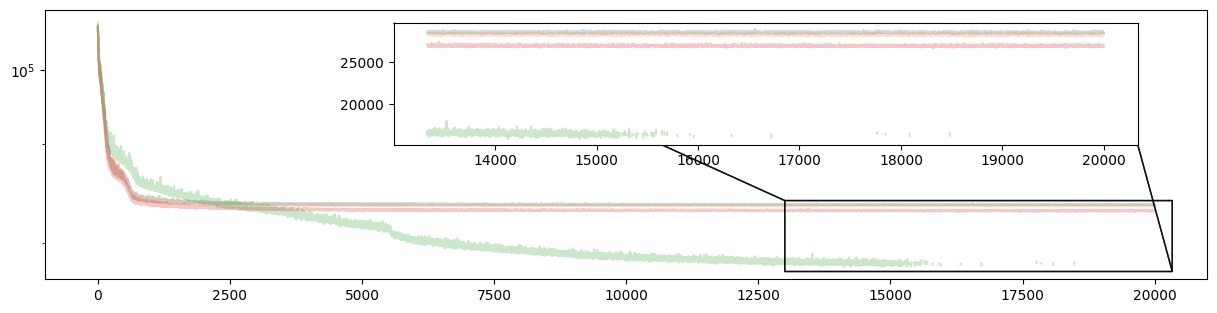

In [16]:
max_iterations = 20000
num_chains = 4

scheduler_stage2 = optax.exponential_decay(
    init_value=5e-3,
    transition_steps=200,
    decay_rate=0.99,
)
optim_stage2 = optax.adabelief(learning_rate=scheduler_stage2)
loss_stage2 = infer.TraceMeanField_ELBO()

svi_keys = jax.random.split(rng_key_, num_chains)
stage2_results_list = []
stage2_guides = []

for i in range(num_chains):
    init_values_stage2_i = get_value_from_index(multi_svi_pixel_median_stage1, i) | {
        'log_psf_corr_center': jnp.zeros((PSF_CORR_PRIOR['box_size_pix'], PSF_CORR_PRIOR['box_size_pix'])),
    }
    init_fun_stage2_i = init_to_value_or_defer(values=init_values_stage2_i)
    guide_stage2_i = autoguide.AutoDiagonalNormal(model, init_loc_fn=init_fun_stage2_i, init_scale=0.01)
    svi_stage2_i = infer.SVI(model, guide_stage2_i, optim_stage2, loss_stage2)
    result_i = svi_stage2_i.run(
        svi_keys[i],
        max_iterations,
        data,
        k_grid.k,
        conj=True,
        n_value=None,
        pixelated=True,
        provided_rms=provided_rms,
        mass_prior_kwargs=MASS_PRIOR_PIXELATED,
        psf_kernel=psf_hst,
        k_psf_values=k_psf,
        enable_psf_corr=True,
        progress_bar=True,
        stable_update=True,
    )
    stage2_guides.append(guide_stage2_i)
    stage2_results_list.append(result_i)


def _stack_or_none(*xs):
    if xs[0] is None:
        return None
    return jnp.stack(xs)


multi_svi_pixel_results_stage2 = jax.tree.map(_stack_or_none, *stage2_results_list)
guide_pixel_stage2 = stage2_guides[0]
multi_svi_pixel_median_stage2 = guide_pixel_stage2.median(multi_svi_pixel_results_stage2.params)
multi_svi_pixel_median_herc_stage2 = median_params2kwargs(
    lambda p, fixed_params={}: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage2,
    jnp.arange(num_chains),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_pixel_results_stage2.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

In [ ]:
# Stage2b removed for now.
# Keep stage2 outputs as the current results for downstream blocks.

multi_svi_pixel_median_stage2_svi = multi_svi_pixel_median_stage2
multi_svi_pixel_median_herc_stage2_svi = multi_svi_pixel_median_herc_stage2


In [ ]:
from lens_images_extension import pixelize_plane as pixelize_plane_single


def plot_stage2_result_set(params_all, kwargs_all, stage_label):
    for i in range(num_chains):
        params_i = get_value_from_index(params_all, i)
        kwargs_i = get_value_from_index(kwargs_all, i)
        corr_field_i = build_psf_corr_factor_field(
            params_i['log_psf_corr_center'],
            psf_hst.shape,
            box_size_pix=PSF_CORR_PRIOR['box_size_pix'],
            log_clip=PSF_CORR_PRIOR['log_clip'],
        )
        psf_kernel_i = params2psf_kernel(params_i)

        plt.figure(figsize=(15, 15))
        plt.suptitle(f'{stage_label} | chain {i}', y=0.92)

        plt.subplot(3, 3, 1)
        plt.imshow(data, norm='log', cmap='twilight', extent=extent, origin='lower')
        plt.title('data')

        plt.subplot(3, 3, 2)
        image_model = lens_image_pixel.model(
            **kwargs_i,
            source_add=True,
            point_source_add=True,
            psf_kernel=psf_kernel_i,
        )
        plt.imshow(image_model, norm='log', cmap='twilight', extent=extent)
        plt.title('model')

        plt.subplot(3, 3, 3)
        plt.imshow((data - image_model) / rms_file, cmap='bwr', vmax=3, vmin=-3, extent=extent)
        plt.contour(mask, levels=[0.5], colors='black', alpha=0.95, linewidth=2, linestyles='dashed', origin='lower', extent=extent)
        plt.title('residual / rms')

        lens_light_only = lens_image_pixel.model(
            **kwargs_i,
            source_add=False,
            point_source_add=False,
            psf_kernel=psf_kernel_i,
        )

        plt.subplot(3, 3, 4)
        plt.imshow(data - lens_light_only, norm='log', cmap='twilight', extent=extent)
        plt.title('data - lens light')

        plt.subplot(3, 3, 5)
        plt.imshow(image_model - lens_light_only, norm='log', cmap='twilight', extent=extent)
        plt.title('source + point source')

        plt.subplot(3, 3, 6)
        source, source_extent = pixelize_plane_single(
            lens_image_pixel,
            kwargs_i,
            pixel_grid_shape,
        )
        plt.imshow(source, extent=source_extent, norm='log', cmap='twilight')
        plt.title('source plane')

        plt.subplot(3, 3, 7)
        plt.imshow(psf_hst, origin='lower', norm='log', cmap='twilight')
        plt.title('original psf')

        plt.subplot(3, 3, 8)
        plt.imshow(psf_kernel_i, origin='lower', norm='log', cmap='twilight')
        plt.title('modified psf')

        plt.subplot(3, 3, 9)
        plt.imshow(corr_field_i, origin='lower', cmap='bwr')
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.title('correction field')

        plt.tight_layout()
        plt.show()


# Stage2 (SVI) result
if 'multi_svi_pixel_median_stage2_svi' in globals() and 'multi_svi_pixel_median_herc_stage2_svi' in globals():
    plot_stage2_result_set(
        multi_svi_pixel_median_stage2_svi,
        multi_svi_pixel_median_herc_stage2_svi,
        'stage2 (SVI)',
    )
else:
    plot_stage2_result_set(
        multi_svi_pixel_median_stage2,
        multi_svi_pixel_median_herc_stage2,
        'stage2 (SVI, fallback=current)',
    )


### Corner plot (after third SVI)

In [ ]:
vars_lens_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
n_corner_draws = 300  # 不要1000，先用200-400更稳

fig_corner = None
for i in range(num_chains):
    params_i = get_value_from_index(multi_svi_pixel_results_stage2.params, i)
    key_i = jax.random.fold_in(rng_key_, i)

    # 逐链采样，降低峰值内存
    samples_all_i = guide_pixel_stage2.sample_posterior(
        key_i, params_i, sample_shape=(n_corner_draws,)
    )

    # 只保留需要画corner的参数
    samples_i = {k: samples_all_i[k] for k in vars_lens_mass}

    # 组装成 ArviZ 需要的 (chain, draw, ...)
    posterior_i = {k: jax.device_get(v)[None, ...] for k, v in samples_i.items()}
    idata_i = az.from_dict(posterior=posterior_i)

    fig_corner = corner(
        idata_i.posterior.isel(chain=0),
        var_names=vars_lens_mass,
        color=f'C{i}',
        fig=fig_corner,
    )


In [18]:
# best_i = int(multi_svi_pixel_results.losses[:, -1000:].mean(axis=1).argmin())

# # lens_light = params2kwargs_gauss_light(get_value_from_index(multi_svi_pixel_median, best_i), 'lens', N_gauss_light, sigma_lims_lens)
# # import pickle

# # with open('lens_light_slice.pkl', 'wb') as f:
# #     pickle.dump(lens_light, f)

# # vars_fixed = vars_lens_light 
# # svi_pixel_median = get_value_from_index(multi_svi_pixel_median, best_i)
# # fixed_params_pixel = {k:svi_pixel_median[k] for k in vars_fixed}
# # model_pixel_hmc_new = condition(model, fixed_params_pixel)

## HMC of the pixel grid model

As with the SVI we can extend the HMC to the full pixel grid model.  Keeping the lens light and parameterized source light fixed at the parameterized SVI solution, and initialize the model with the pixelated SVI solution.  Given the complex 

In [23]:
vars_pixel = ['pixels_wn_source_grid']
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
vars_psf = ['ra_ps', 'dec_ps', 'log10_amp_ps', 'log10_amp_lens_ps']
vars_psf_corr = ['log_psf_corr_center']

multi_svi_pixel_median_vars = {
    k: multi_svi_pixel_median_stage2[k]
    for k in vars_mass + vars_power + vars_pixel + vars_other + vars_lens_light + vars_psf + vars_psf_corr
}

unconstrined_svi_pixel_median = jax.vmap(
    lambda p: infer.util.unconstrain_fn(
        model,
        (data, k_grid.k),
        {
            'conj': False,
            'pixelated': True,
            'provided_rms': provided_rms,
            'mass_prior_kwargs': MASS_PRIOR_PIXELATED,
            'psf_kernel': psf_hst,
            'k_psf_values': k_psf,
            'enable_psf_corr': True,
        },
        p,
    )
)(multi_svi_pixel_median_vars)

unconstrined_svi_pixel_median = {k: v.astype(jnp.float64) for k, v in unconstrined_svi_pixel_median.items()}
rng_key, rng_key_ = jax.random.split(rng_key)


In [24]:
from numpyro.infer import NUTS, MCMC
from custom_gibbs import MultiHMCGibbs

init_fun_pixel = init_to_value_or_defer(values=get_value_from_index(multi_svi_pixel_median_stage2, 0))

inner_kernels = [
    NUTS(
        model,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.95,
        max_tree_depth=10,
        dense_mass=[
            ('n_source_grid', 'rho_source_grid', 'sigma_source_grid'),
            ('A_lens', 'sigma_lens', 'e_lens', 'center_lens'),
        ],
    ),
    NUTS(
        model,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.9,
        max_tree_depth=10,
        dense_mass=[('center_1',), ('theta_E_1',), ('e_1', 'gamma_1', 'gamma_sheer_1')],
    ),
    NUTS(
        model,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.9,
        max_tree_depth=10,
        dense_mass=[('ra_ps', 'dec_ps', 'log10_amp_ps', 'log10_amp_lens_ps')],
    ),
]

outer_kernel = MultiHMCGibbs(
    inner_kernels,
    gibbs_sites_list=[
        vars_pixel + vars_power + vars_lens_light + vars_other,
        vars_mass,
        vars_psf + vars_psf_corr,
    ],
)

mcmc_pixel = MCMC(
    outer_kernel,
    num_warmup=100,
    num_samples=100,
    num_chains=num_chains,
    progress_bar=True,
    chain_method='vectorized'
)

batch_number = 1
last_states = []
batch_list = []
for i in range(batch_number):
    if i == 0:
        mcmc_pixel.run(
            rng_key_,
            data,
            k_grid.k,
            conj=False,
            pixelated=True,
            provided_rms=provided_rms,
            mass_prior_kwargs=MASS_PRIOR_PIXELATED,
            psf_kernel=psf_hst,
            k_psf_values=k_psf,
            enable_psf_corr=True,
            init_params=unconstrined_svi_pixel_median
        )
        last_states.append(jax.device_get(mcmc_pixel.last_state))
    else:
        mcmc_pixel.post_warmup_state = mcmc_pixel.last_state
        mcmc_pixel.run(
            mcmc_pixel.post_warmup_state.rng_key,
            data,
            k_grid.k,
            conj=False,
            pixelated=True,
            provided_rms=provided_rms,
            mass_prior_kwargs=MASS_PRIOR_PIXELATED,
            psf_kernel=psf_hst,
            k_psf_values=k_psf,
            enable_psf_corr=True,
        )
        last_states.append(jax.device_get(mcmc_pixel.last_state))

    mcmc_pixel._states = jax.device_get(mcmc_pixel._states)
    mcmc_pixel._states_flat = jax.device_get(mcmc_pixel._states_flat)
    mcmc_chain = az.from_numpyro(mcmc_pixel)
    mcmc_chain.to_netcdf('/mnt/lustre/tianli/quasar_hmc/WFI2033_psfcorrection'+str(i)+'.nc')
    batch_list.append(mcmc_chain)


sample: 100%|██████████| 200/200 [25:28<00:00,  7.64s/it]


In [1]:
import arviz as az
import numpy as np
batch_list = []
for i in range(1):
    current_batch = az.from_netcdf("/mnt/lustre/tianli/quasar_hmc/WFI2033_psf_correction0.nc")
    batch_list.append(current_batch)
print('concat')  
inf_data_pixel = az.concat(*batch_list, dim='draw')
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens', 'e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_other = []
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
print(f'divergences per chain per step:\n {inf_data_pixel.sample_stats.diverging.values.sum(axis=1).T}')
#az.summary(inf_data_pixel, var_names=vars_mass + vars_power + vars_other)
az.summary(inf_data_pixel.sel(chain=np.array([0,1,2,3])), var_names=vars_mass + vars_power + vars_other)

concat
divergences per chain per step:
 [[0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_E_1[0],1.837,0.001,1.836,1.838,0.000,0.000,6.0,59.0,1.75
gamma_1[0],1.967,0.006,1.956,1.975,0.003,0.001,6.0,33.0,1.99
"e_1[0, 0]",-0.097,0.002,-0.101,-0.095,0.001,0.000,5.0,22.0,1.98
"e_1[1, 0]",-0.013,0.001,-0.015,-0.011,0.001,0.000,5.0,32.0,2.02
center_1[0],-0.065,0.001,-0.067,-0.064,0.001,0.000,6.0,33.0,1.86
center_1[1],0.010,0.002,0.007,0.012,0.001,0.000,5.0,25.0,2.13
"gamma_sheer_1[0, 0]",0.071,0.001,0.069,0.073,0.000,0.000,6.0,31.0,1.87
"gamma_sheer_1[1, 0]",-0.063,0.001,-0.065,-0.062,0.000,0.000,6.0,22.0,1.88
n_source_grid[0],0.003,0.001,0.001,0.005,0.000,0.000,14.0,53.0,1.20
rho_source_grid[0],6.315,3.276,1.952,11.389,1.247,0.261,7.0,81.0,1.63


/tmp/ipykernel_729637/3999965567.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


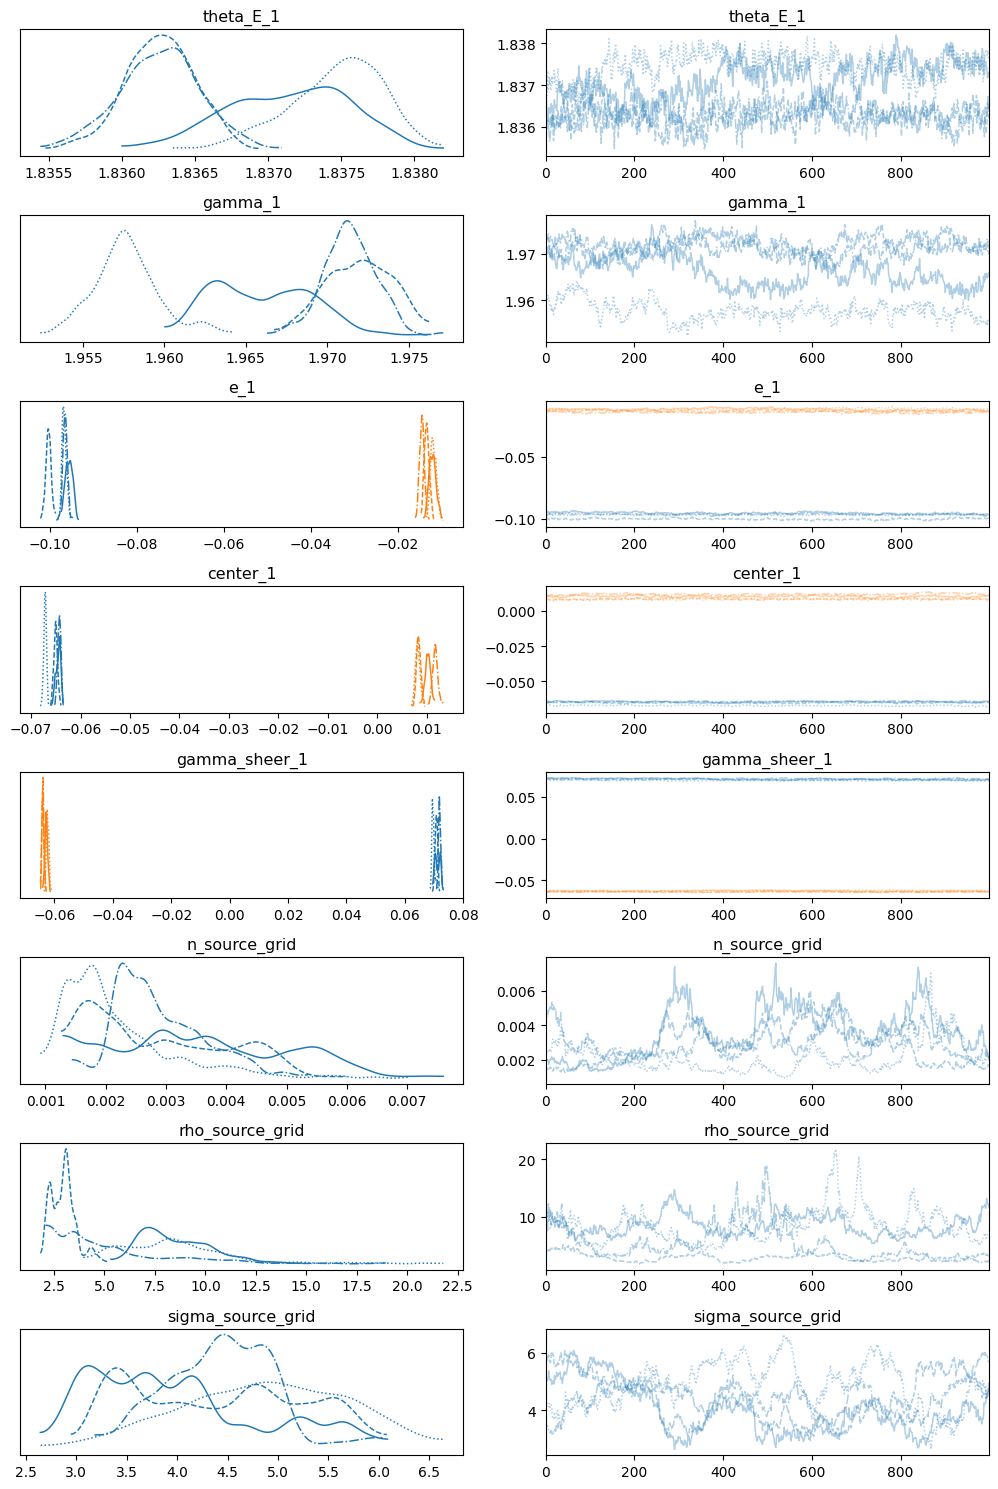

In [2]:
import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(inf_data_pixel.sel(chain=np.array([0,1, 2 ,3])),var_names=vars_mass + vars_power + vars_other , figsize=(10, 15))
plt.tight_layout()

/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust a

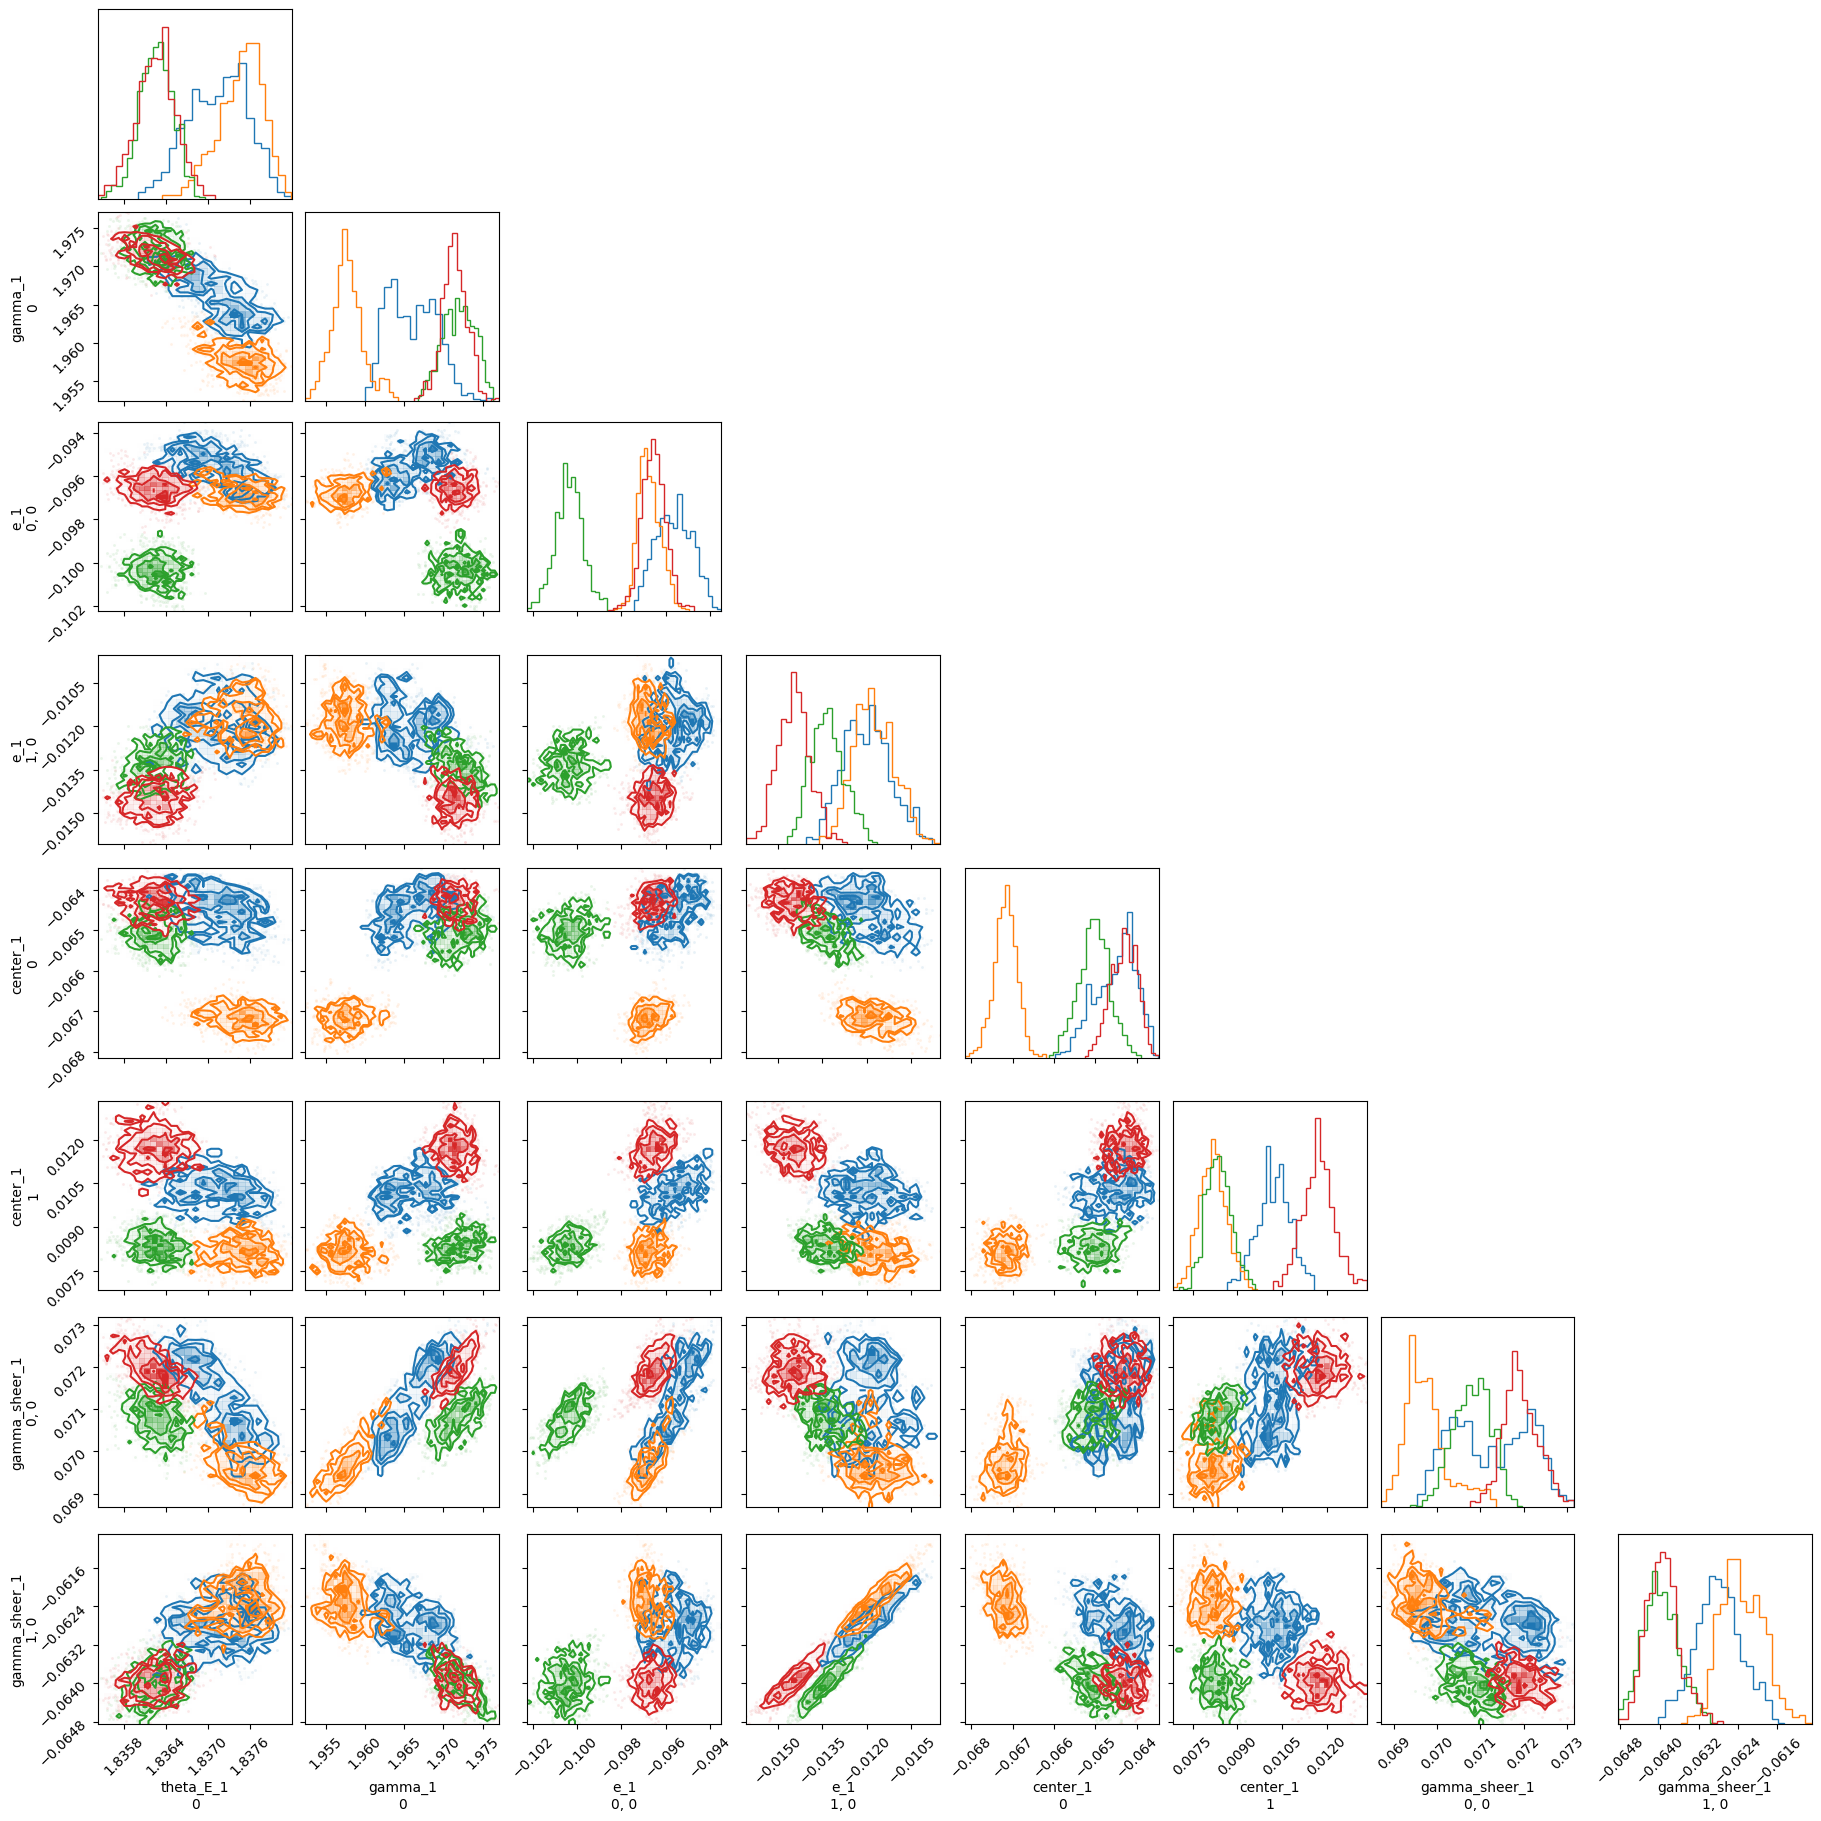

In [5]:
import corner.corner as corner
fig_corner = None
for i in range(4):
    fig_corner = corner(
        inf_data_pixel.posterior.isel(chain=i),
        var_names=vars_mass,
        color=f'C{i}',
        fig=fig_corner,
    )

In [3]:
%load_ext autoreload
%autoreload 2
import sys
import os
import warnings
warnings.simplefilter("ignore")
# parentdir = os.path.abspath('../..')
# sys.path.insert(0, parentdir) 
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

pix_scale = 0.031  # arcsec / pixel (JWST)

DATA_DIR = "../../Data/WFI2033"
raw_data_path = os.path.join(DATA_DIR, "jw01198-o004_t004_nircam_clear-f115w_i2d.fits")
data_path = os.path.join(DATA_DIR, "jw01198-o004_t004_nircam_clear-f115w_i2d_cut_x6985_y3594_150.fits")
mask_path = os.path.join(DATA_DIR, "mask.fits")
# mask_out is set to all True by design (full image likelihood region)
with fits.open(raw_data_path, memmap=True) as hdul_raw:
    exposure_time = float(hdul_raw[0].header.get("EXPTIME", hdul_raw[0].header.get("TEXPTIME", 1.0)))

with fits.open(data_path, memmap=True) as hdul:
    data = jnp.array(hdul["SCI"].data) if "SCI" in hdul else jnp.array(hdul[0].data)
    rms_file = jnp.array(hdul["ERR"].data)

mask = jnp.array(fits.getdata(mask_path), dtype=bool)
mask_out = jnp.ones_like(data, dtype=bool)
mask =  jnp.array(mask_out, dtype=bool)


corner_pixel = 10
bkg_corner = np.array(data[:corner_pixel, :corner_pixel])
bkg_mean = float(np.nanmean(bkg_corner))
bkg_rms = float(np.nanstd(bkg_corner))

data = data - bkg_mean

[CudaDevice(id=0)]


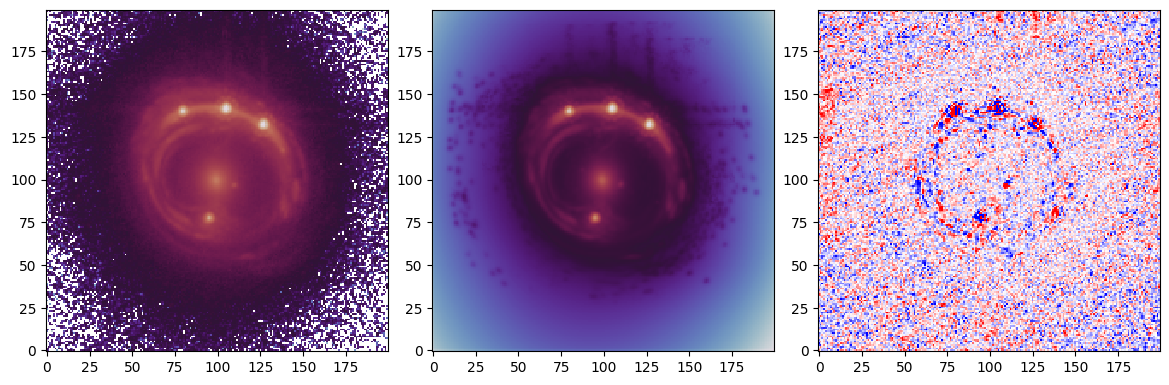

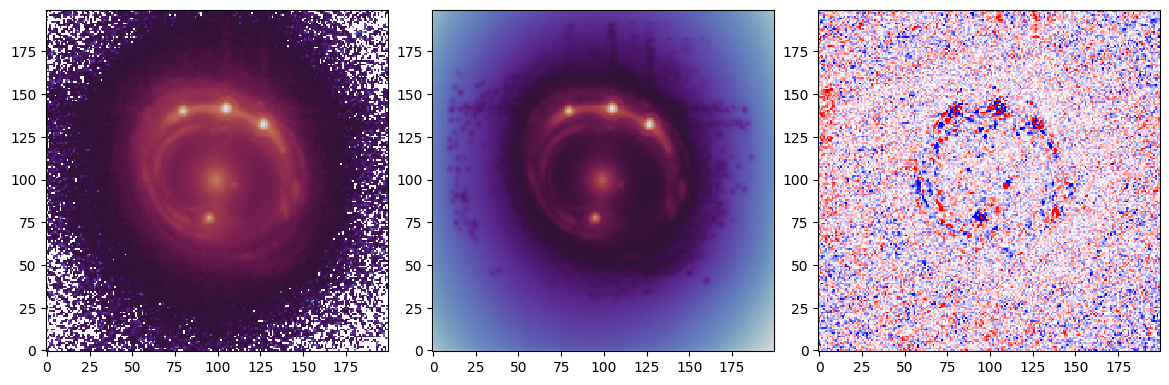

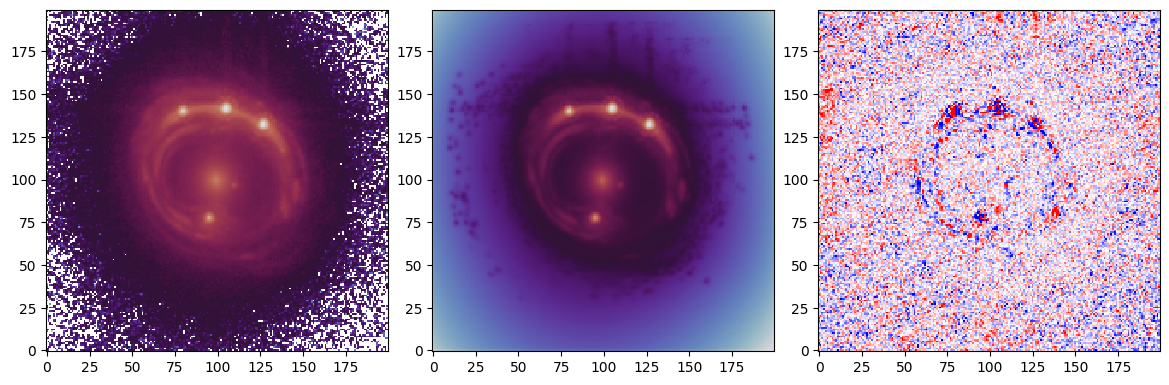

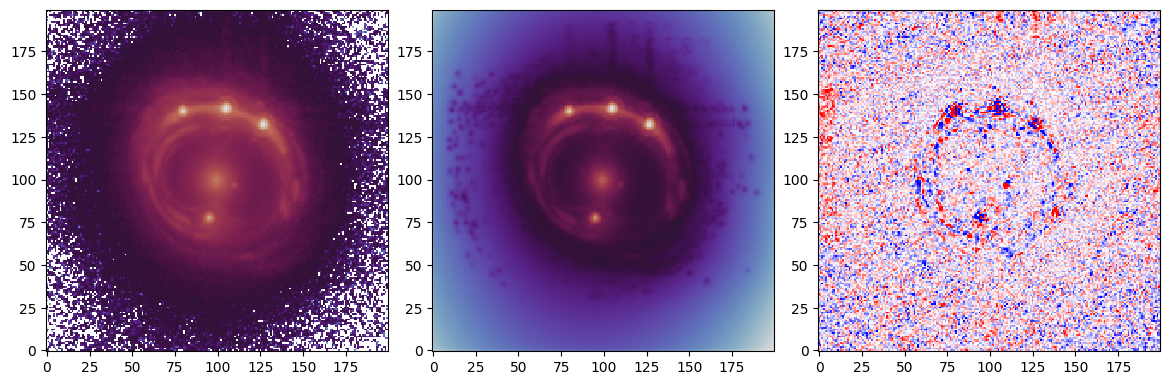

In [13]:
for i in range(4):
    plt.figure(figsize = (15,5))
    plt.subplot(1,4,1)
    plt.imshow(data, norm = 'log', cmap = 'twilight', origin = 'lower')
    plt.subplot(1,4,2)
    model_image = inf_data_pixel.posterior.model_image.median(axis = 1)[i,:,:]
    plt.imshow(model_image, norm = 'log', cmap = 'twilight', origin = 'lower')
    plt.subplot(1,4,3)
    plt.imshow((data  - model_image) / rms_file, cmap = 'bwr', vmax = 3, vmin = -3, origin = 'lower')